## Table of Contents

1. [Setup & Dependencies](#setup--dependencies)
2. [Environment Configuration](#environment-configuration)
3. [Motor Definition](#motor-definition)
4. [Rocket Configuration](#rocket-configuration)
5. [Flight Simulation](#flight-simulation)
6. [Results Analysis](#results-analysis)
7. [Design Utilities](#design-utilities)

## Setup & Dependencies

In [1]:
import sys
!{sys.executable} -m pip install rocketpy


[notice] A new release of pip available: 22.3 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from rocketpy import Environment, SolidMotor, Rocket, Flight
import matplotlib.pyplot as plt
import datetime
from pathlib import Path

# Define paths relative to the notebook location
DATA_DIR = Path("../data")
MOTOR_DIR = DATA_DIR / "motor"
AERO_DIR = DATA_DIR / "aerodynamics"
OUTPUT_DIR = Path("../output")

## Environment Configuration

The `Environment` class defines the atmospheric conditions, wind profiles, and gravity model for the launch site.

 **Launch Site:** ISRO Sriharikota Range (SHAR)  
 **Documentation:** [RocketPy Environment Class](https://docs.rocketpy.org/en/latest/notebooks/environment/environment_class_usage.html)

In [3]:
# Launch site coordinates (Sriharikota, India)
LAUNCH_LATITUDE = 13.4685560
LAUNCH_LONGITUDE = 80.0042220
LAUNCH_ELEVATION = 20.6  # meters above sea level

env = Environment(
    latitude=LAUNCH_LATITUDE,
    longitude=LAUNCH_LONGITUDE,
    elevation=LAUNCH_ELEVATION
)

### Setting Launch Date & Weather Data

Configure the launch date to fetch weather forecasts from NOAA's GFS model.

> **Note:** Weather forecasts are typically available up to 16 days in advance.

**Options:**
- Set a specific date manually
- Use a date relative to today (uncomment the alternative code)

In [4]:
# Option 1: Specific date (manual)
LAUNCH_YEAR = 2025
LAUNCH_MONTH = 12
LAUNCH_DAY = 30
LAUNCH_HOUR = 18  # UTC

env.set_date((LAUNCH_YEAR, LAUNCH_MONTH, LAUNCH_DAY, LAUNCH_HOUR))

# Option 2: Relative to current date (uncomment to use)
# tomorrow = datetime.date.today() + datetime.timedelta(days=1)
# env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12))

In [5]:
# Fetch atmospheric data from GFS forecast
env.set_atmospheric_model(type="Forecast", file="GFS")


Gravity Details

Acceleration of gravity at surface level:    9.7830 m/s²
Acceleration of gravity at   5.000 km (ASL): 9.7677 m/s²


Launch Site Details

Launch Date: 2025-12-30 18:00:00 UTC
Launch Site Latitude: 13.46856°
Launch Site Longitude: 80.00422°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 1042247.58 E    1494478.17 N
Launch Site UTM zone: 43P
Launch Site Surface Elevation: 44.7 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 5.000 km
Forecast Time Period: from 2025-12-25 06:00:00 to 2026-01-10 06:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From -90.0° to 90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 2.25 m/s
Surface Wind Direction: 358.94°
Surface Wind Heading: 178.94°
Surface Pressure: 1000.00 hPa
Surface Temperature: 294.53 K
Surface Air Density: 1.183 kg/m³
Surface Speed of Sound: 344.04 m/s


Earth Model Details

Earth Radius at Launch si

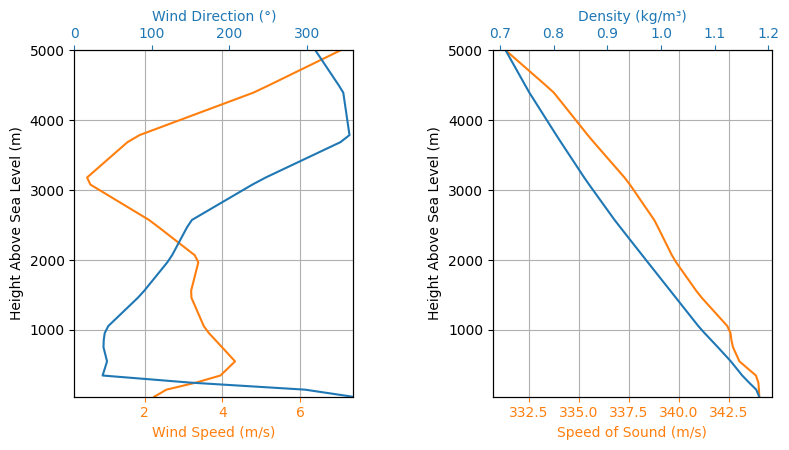

In [6]:
# Display environment information
env.max_expected_height = 5000  # meters - adjusts plot limits
env.info()

## Motor Definition

### Inferno Motor

Motor data based on thrust curve simulated by OpenMotor during Static Fire Test-3 (Inferno-3) conducted by Team Ignition.

**Motor Specifications:**
- **Classification:** K1120
- **Total Impulse:** ~2100 Ns
- **Burn Time:** 2.5 seconds
- **Propellant Mass:** 1.82 kg

In [7]:
class RocketMotorCasing:
    """Calculate inertia properties for a hollow cylindrical motor casing."""
    
    def __init__(self, casing_mass, casing_outer_radius, casing_inner_radius, casing_height):
        self.casing_mass = casing_mass
        self.casing_outer_radius = casing_outer_radius
        self.casing_inner_radius = casing_inner_radius
        self.casing_height = casing_height

    def calculate_dry_inertia(self):
        """Calculate moments of inertia for the empty casing (hollow cylinder)."""
        I11 = I22 = (1/12) * self.casing_mass * (
            3 * (self.casing_outer_radius**2 + self.casing_inner_radius**2) + self.casing_height**2
        )
        I33 = (1/2) * self.casing_mass * (
            self.casing_outer_radius**2 - self.casing_inner_radius**2
        )
        return I11, I22, I33


# Motor casing properties
casing = RocketMotorCasing(
    casing_mass=0.964,           # kg (without fuel)
    casing_outer_radius=0.075,   # m
    casing_inner_radius=0.069,   # m
    casing_height=0.585          # m
)

dry_inertia = casing.calculate_dry_inertia()
print(f"Motor Casing Dry Inertia: {dry_inertia}")

Motor Casing Dry Inertia: (0.029995100999999993, 0.029995100999999993, 0.00041644799999999966)


In [8]:
# Define the Inferno solid motor
Inferno = SolidMotor(
    thrust_source=str(MOTOR_DIR / "inferno_k1120.eng"),
    dry_mass=5.0,  # kg (Total - Propellant)
    dry_inertia=(0.125, 0.125, 0.002),
    nozzle_radius=50 / 2000,  # m
    grain_number=4,
    grain_density=1841,  # kg/m³
    grain_outer_radius=63 / 2000,  # m
    grain_initial_inner_radius=33 / 2000,  # m
    grain_initial_height=115 / 1000,  # m
    grain_separation=1 / 1000,  # m
    grains_center_of_mass_position=0.230,  # m from nozzle
    center_of_dry_mass_position=0.200,  # m from nozzle
    nozzle_position=0,  # reference point
    burn_time=2.5,  # seconds
    throat_radius=11 / 2000,  # m
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

c:\Users\VICTUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\rocketpy\motors\motor.py:990: UserWarning: burn_time argument (0, 2.5) is out of thrust source time range. Using thrust_source boundary times instead: (0, 1.95) s.
If you want to change the burn out time of the curve please use the 'reshape_thrust_curve' argument.
  warnings.warn(


Nozzle Details
Nozzle Radius: 0.025 m
Nozzle Throat Radius: 0.0055 m

Grain Details
Number of Grains: 4
Grain Spacing: 0.001 m
Grain Density: 1841 kg/m3
Grain Outer Radius: 0.0315 m
Grain Inner Radius: 0.0165 m
Grain Height: 0.115 m
Grain Volume: 0.000 m3
Grain Mass: 0.479 kg

Motor Details
Total Burning Time: 2.5 s
Total Propellant Mass: 1.916 kg
Structural Mass Ratio: 0.723
Average Propellant Exhaust Velocity: 1158.576 m/s
Average Thrust: 887.725 N
Maximum Thrust: 1182.8406 N at 1.05 s after ignition.
Total Impulse: 2219.313 Ns



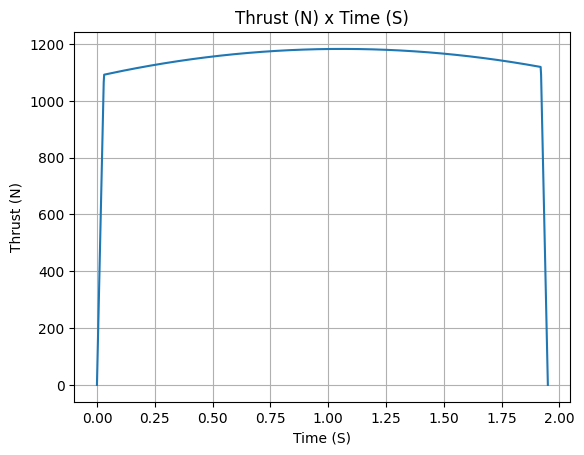

In [9]:
# Display motor characteristics
Inferno.info()

## Rocket Configuration

### PIONEER Specifications

| Parameter | Value |
|-----------|-------|
| Diameter | 102 mm |
| Length | ~1.92 m |
| Dry Mass | 7.2 kg |
| Nose Cone | Ogive, 250 mm |
| Fins | 4x Trapezoidal |

In [10]:
class RocketBody:
    """Calculate inertia properties for the rocket airframe."""
    
    def __init__(self, body_mass, outer_radius, inner_radius, body_height):
        self.body_mass = body_mass
        self.outer_radius = outer_radius
        self.inner_radius = inner_radius
        self.body_height = body_height

    def calculate_inertia(self):
        """Calculate moments of inertia for the airframe (hollow cylinder)."""
        I11 = I22 = (1/12) * self.body_mass * (
            3 * (self.outer_radius**2 + self.inner_radius**2) + self.body_height**2
        )
        I33 = (1/2) * self.body_mass * (
            self.outer_radius**2 - self.inner_radius**2
        )
        return I11, I22, I33


# Rocket body properties
rocket_body = RocketBody(
    body_mass=7.2,        # kg (without motor)
    outer_radius=0.051,   # m
    inner_radius=0.049,   # m
    body_height=1.92      # m
)

body_inertia = rocket_body.calculate_inertia()
print(f"Rocket Body Inertia: {body_inertia}")

Rocket Body Inertia: (2.2208436, 2.2208436, 0.0007199999999999972)


In [11]:
# Initialize the PIONEER rocket
PIONEER = Rocket(
    radius=102 / 2000,  # m (body radius)
    mass=7.2,  # kg (dry mass without motor)
    inertia=(1.9528218, 1.9528218, 0.0003564),
    power_off_drag=str(AERO_DIR / "power_off_drag.csv"),
    power_on_drag=str(AERO_DIR / "power_on_drag.csv"),
    center_of_mass_without_motor=1.03,  # m from nose
    coordinate_system_orientation="nose_to_tail",
)

# Add rail buttons for launch guidance
rail_buttons = PIONEER.set_rail_buttons(
    upper_button_position=1.03,  # m from nose
    lower_button_position=1.90,  # m from nose
    angular_position=45,  # degrees
)

In [12]:
# Mount the motor
PIONEER.add_motor(Inferno, position=1.92)  # m from nose (at tail)

### Aerodynamic Surfaces

**Position Reference:**
- Nose cone position = tip of the nose
- Fin position = root chord leading edge
- All positions measured from nose tip (coordinate system: nose_to_tail)

In [13]:
# Add nose cone
nose_cone = PIONEER.add_nose(
    length=0.25,  # m
    kind="ogive",
    position=0  # at the tip
)

# Add fin set
fin_set = PIONEER.add_trapezoidal_fins(
    n=4,
    root_chord=0.24,   # m
    tip_chord=0.0575,  # m
    span=0.125,        # m
    position=1.63,     # m from nose
    cant_angle=0,      # degrees
)


Inertia Details

Rocket Mass: 7.200 kg (without motor)
Rocket Dry Mass: 12.200 kg (with unloaded motor)
Rocket Loaded Mass: 14.116 kg
Rocket Structural Mass Ratio: 0.864
Rocket Inertia (with unloaded motor) 11: 3.483 kg*m2
Rocket Inertia (with unloaded motor) 22: 3.483 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.002 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.051 m
Rocket Frontal Area: 0.008171 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.283 m
Rocket Center of Dry Mass - Nozzle Exit: 0.607 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.377 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.051 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 12.686/rad

Center of Pressure

Nose

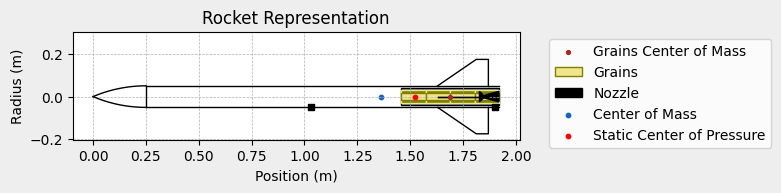


Mass Plots
----------------------------------------


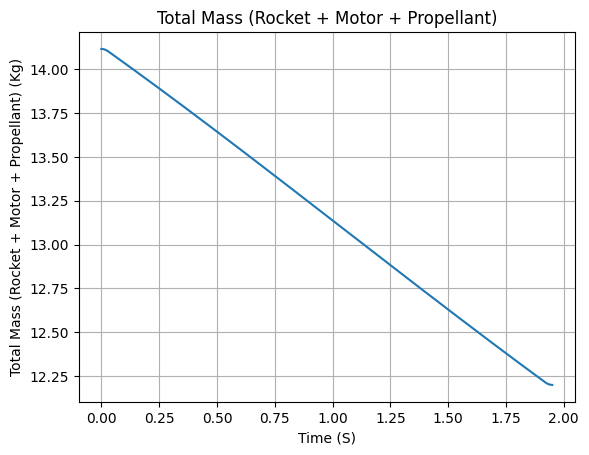

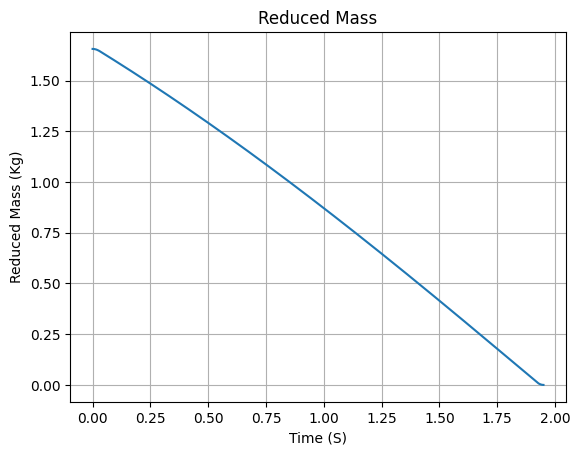


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


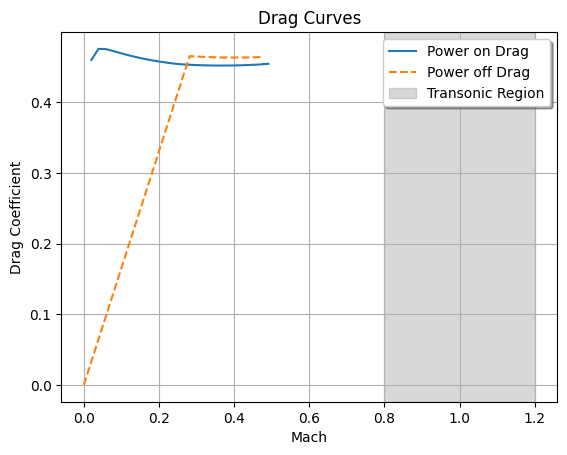


Stability Plots
--------------------


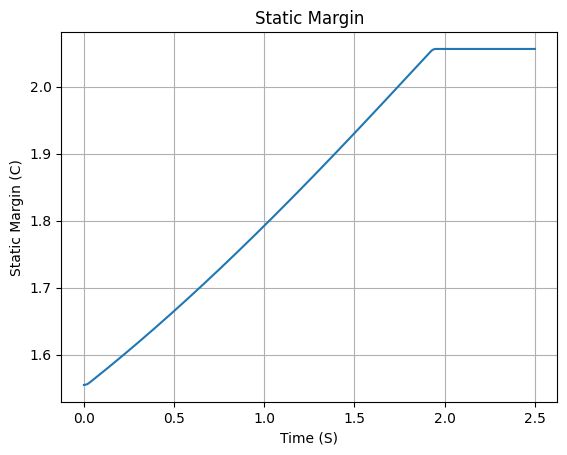

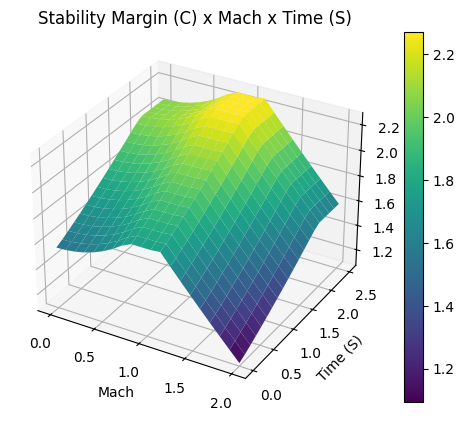


Thrust-to-Weight Plot
----------------------------------------


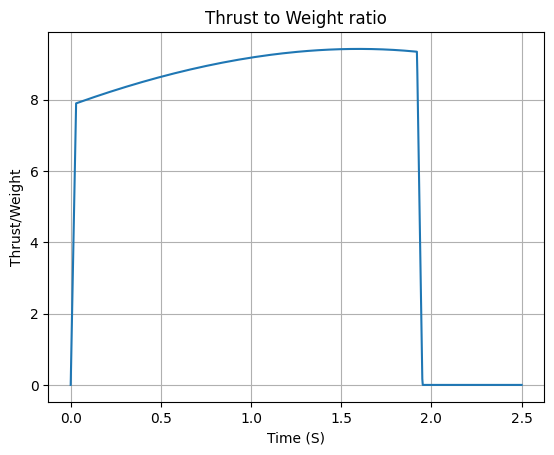

In [14]:
# Display complete rocket information
PIONEER.all_info()

### Recovery System

PIONEER uses a single main parachute deployed at apogee.

> **Note:** Running this cell multiple times will add duplicate parachutes. Re-run the rocket definition cells if needed, or use:
> ```python
> PIONEER.parachutes.remove(Main)
> ```

In [15]:
# Optional: Drogue parachute (uncomment to enable)
# Drogue = PIONEER.add_parachute(
#     "Drogue",
#     cd_s=1.5,  # drag coefficient × reference area
#     trigger="apogee",
#     sampling_rate=105,
#     lag=1,  # seconds
#     noise=(0, 8.3, 0.5),
# )

# Main parachute
Main = PIONEER.add_parachute(
    "Main",
    cd_s=6.36,  # drag coefficient × reference area
    trigger="apogee",
    sampling_rate=105,
    lag=2,  # seconds
    noise=(0, 8.3, 0.5),
)

## Flight Simulation

**Launch Rail Configuration:**
- Length: 4.0 m
- Inclination: 85° (5° from vertical)

**Heading Reference:**
| Heading | Direction |
|---------|----------|
| 0° | North |
| 90° | East |
| 180° | South |
| 270° | West |

In [16]:
# Execute flight simulation
test_flight = Flight(
    rocket=PIONEER,
    environment=env,
    rail_length=4.0,  # m
    inclination=85,   # degrees from horizontal
    heading=90        # degrees (East)
)

## Results Analysis

View comprehensive flight data including:
- Trajectory plots
- Velocity and acceleration profiles
- Stability analysis
- Recovery performance


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 44.65 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.382 | e1: 0.040 | e2: -0.017 | e3: 0.923
Euler Angles - Spin φ : -45.00° | Nutation θ: -5.00° | Precession ψ: 270.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.555 c


Surface Wind Conditions

Frontal Surface Wind Speed: 0.04 m/s
Lateral Surface Wind Speed: -2.25 m/s


Launch Rail

Launch Rail Length: 4.0 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.317 s
Rail Departure Velocity: 21.001 m/s
Rail Departure Stability Margin: 1.623 c
Rail Departure Angle of Attack: 6.113°
Rail Departure Thrust-Weight Ratio: 8.376
Rail Departure Reynolds Number: 1.400e+05


Burn out State

Burn out time: 2.500 s
Altitude at burn out: 263.029 m (ASL) | 218.378 m (AGL)
Rocket speed at burn out: 140.215 m/s
Freestream vel

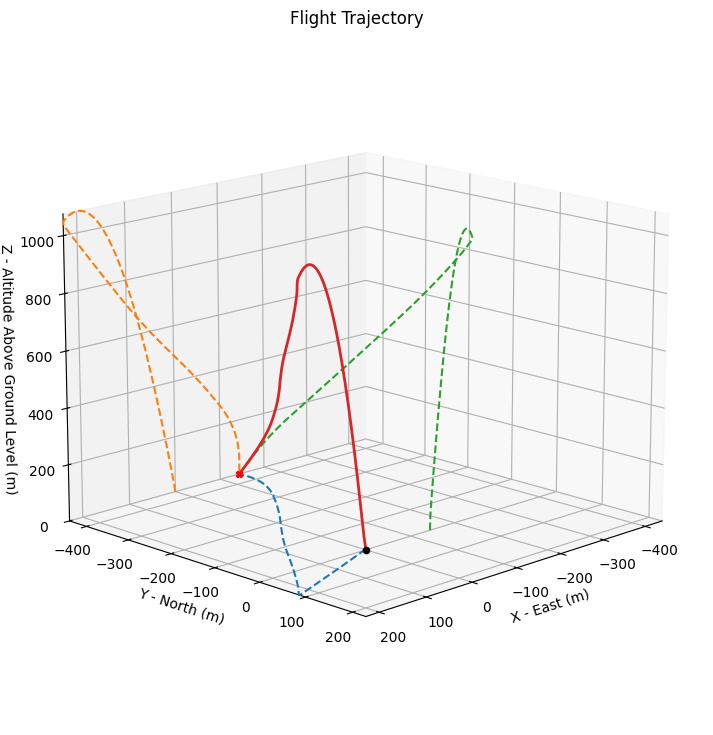



Trajectory Kinematic Plots



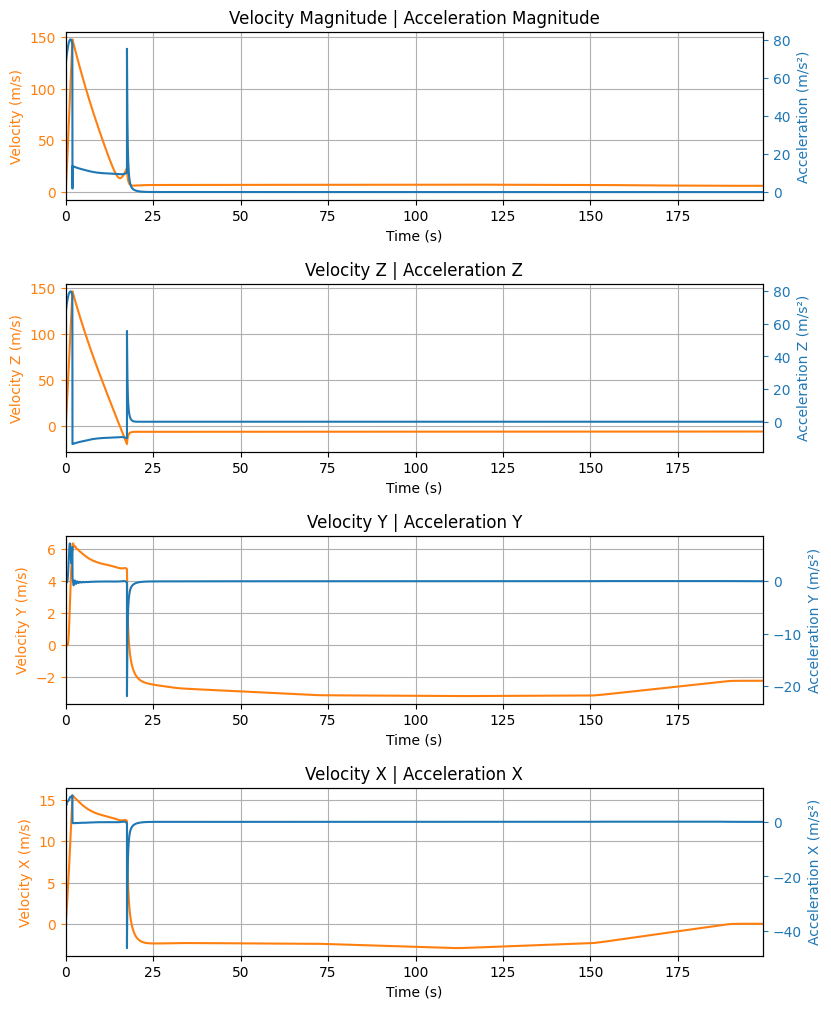



Angular Position Plots



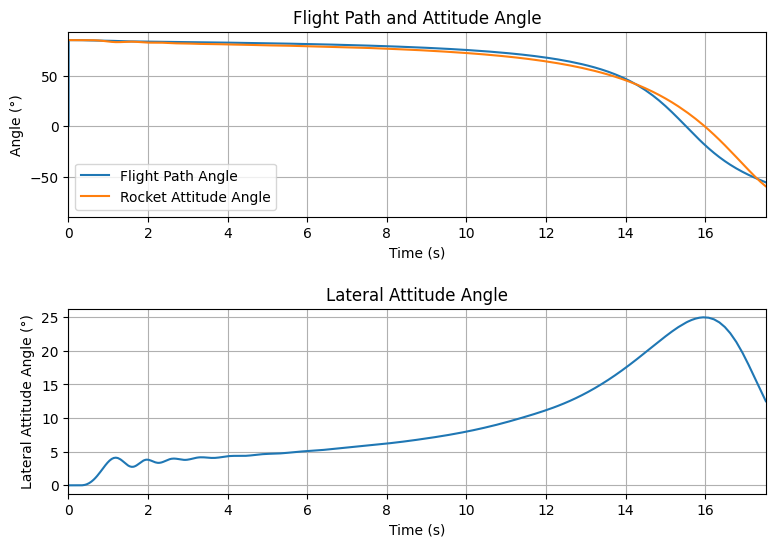



Path, Attitude and Lateral Attitude Angle plots



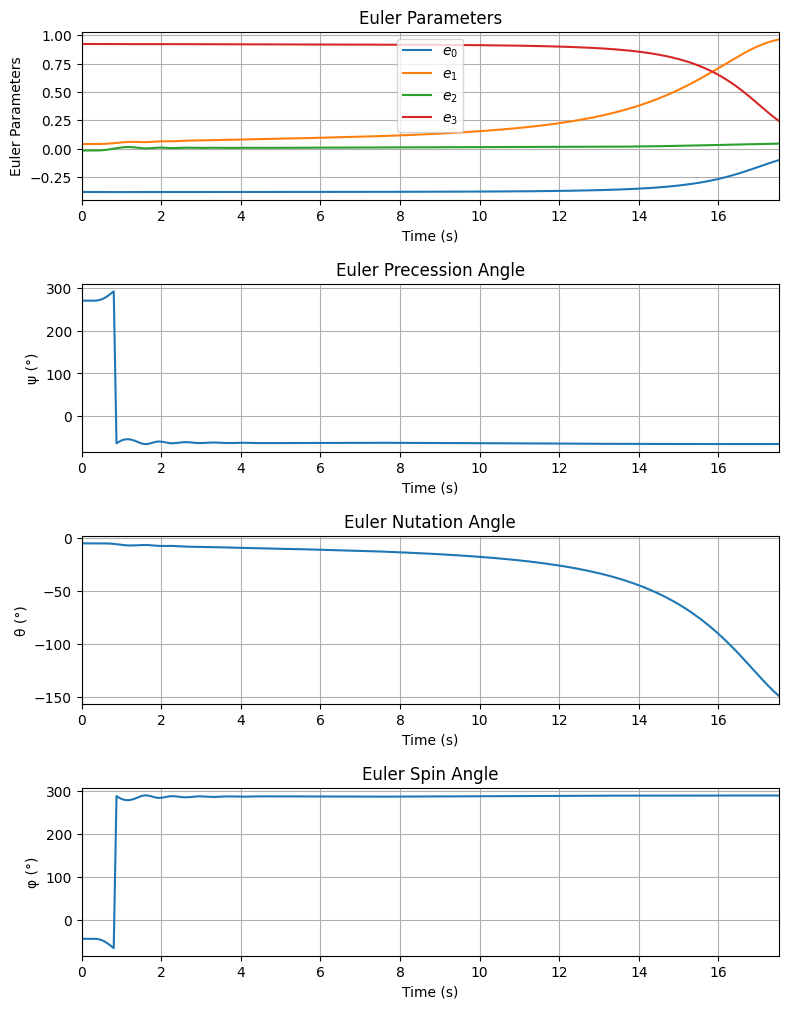



Trajectory Angular Velocity and Acceleration Plots



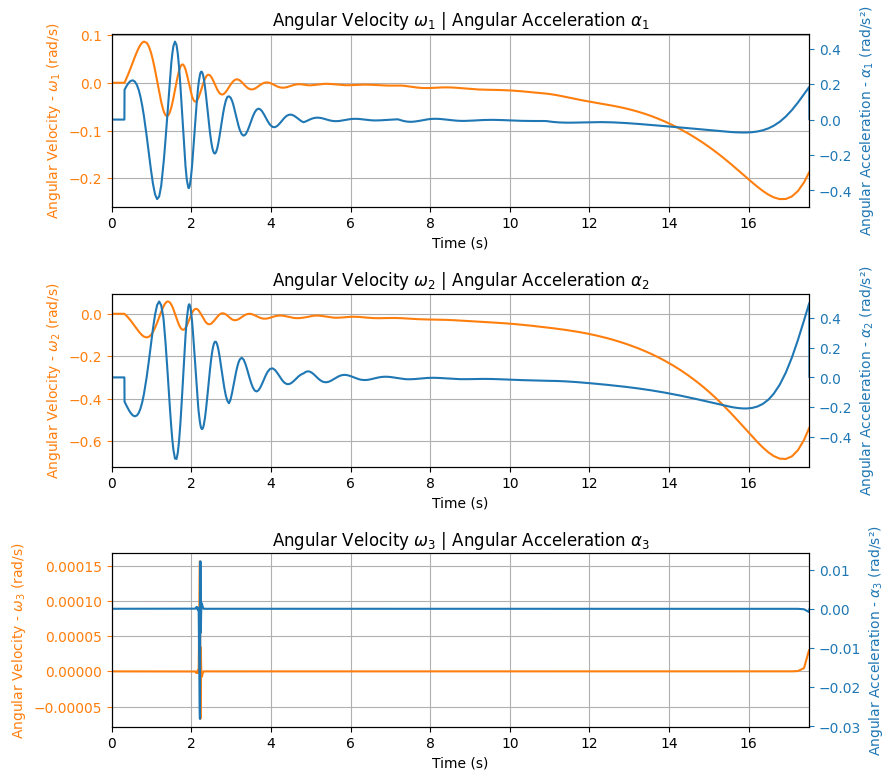



Aerodynamic Forces Plots



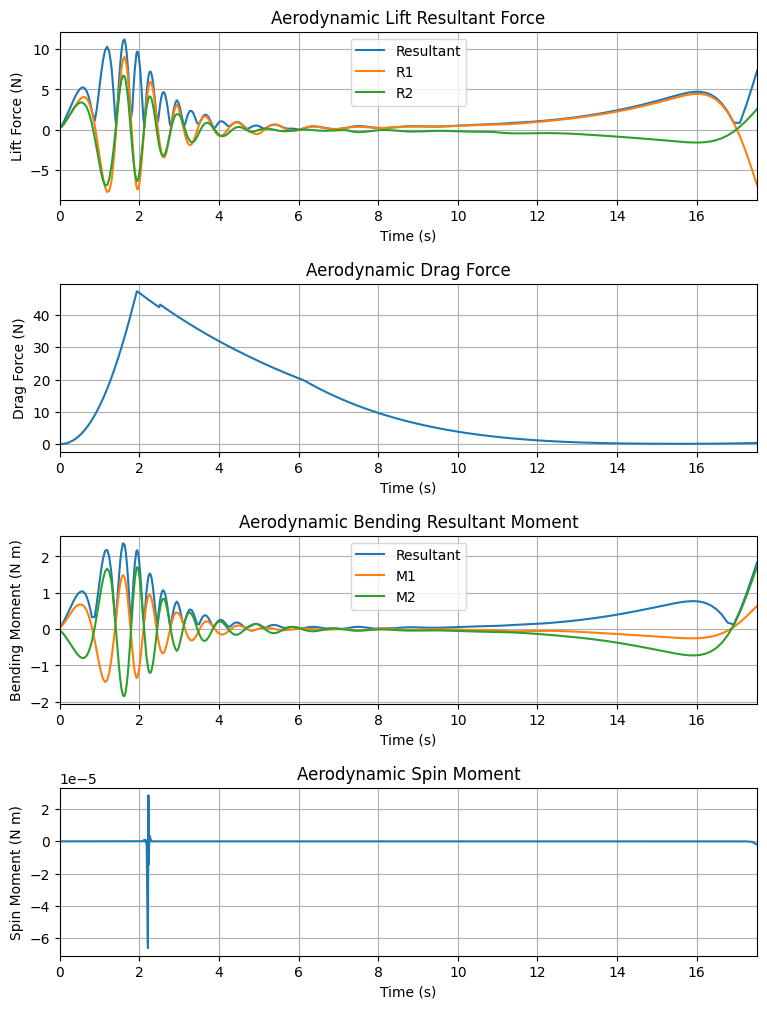



Rail Buttons Forces Plots



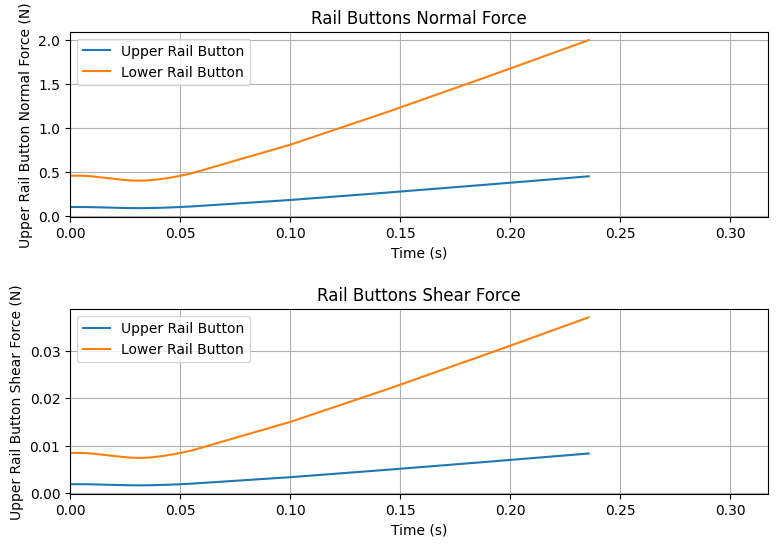



Trajectory Energy Plots



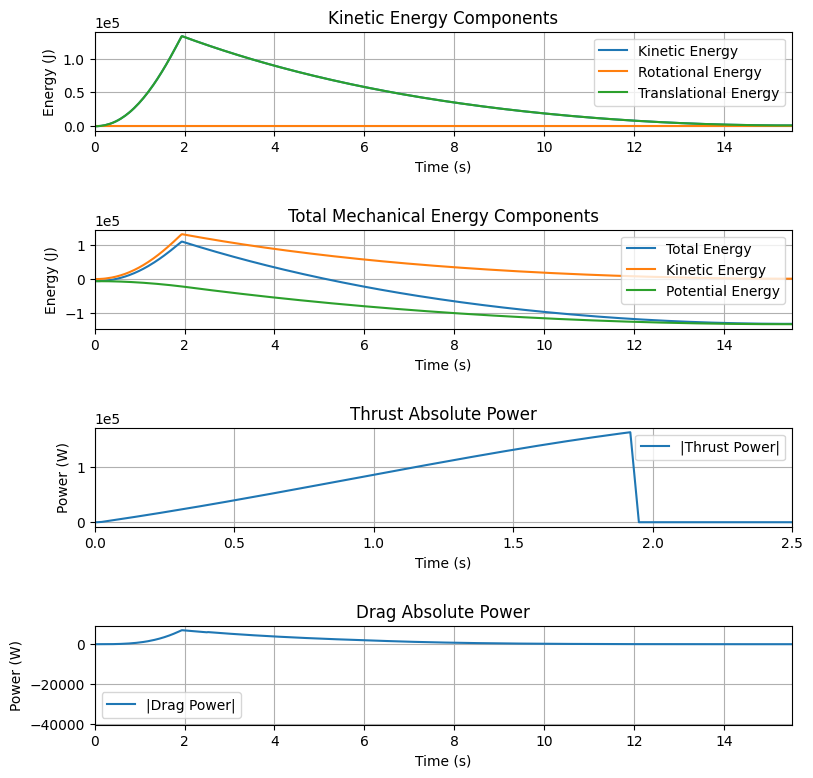



Trajectory Fluid Mechanics Plots



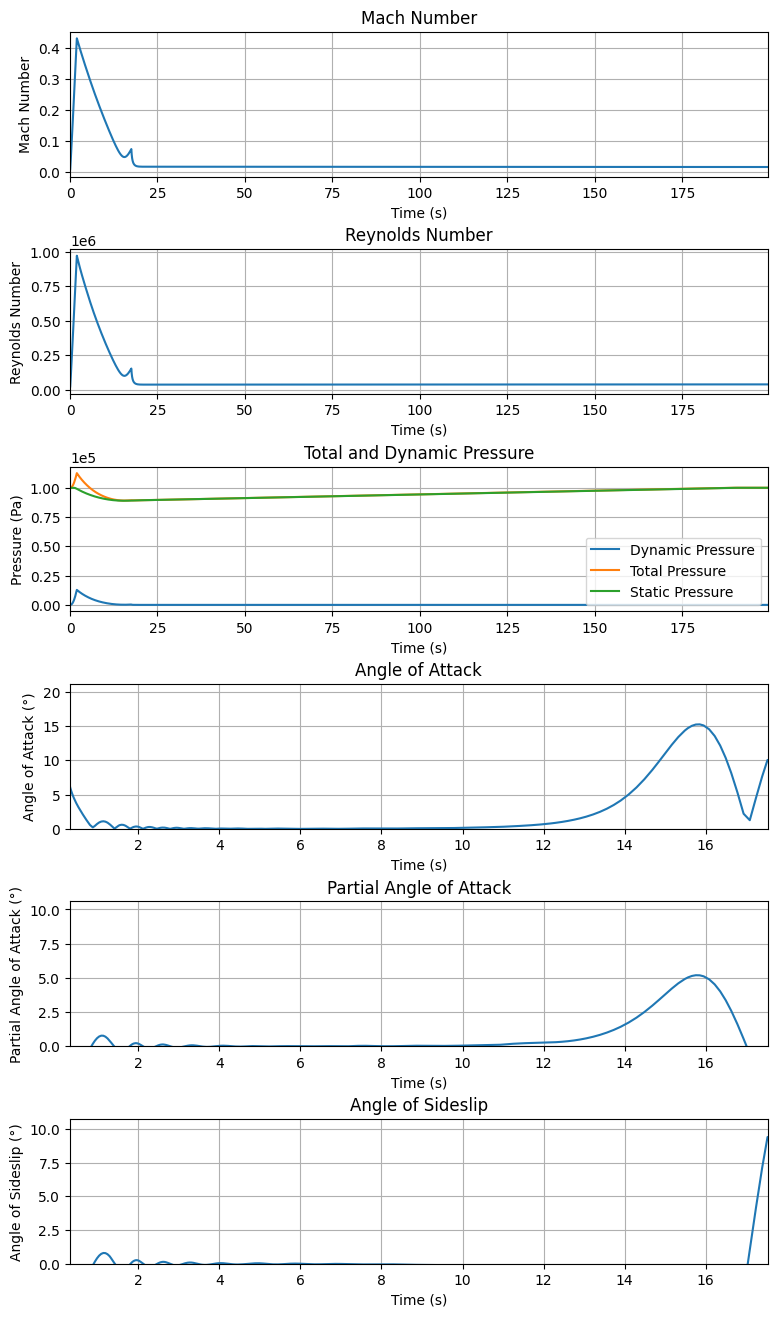



Trajectory Stability and Control Plots



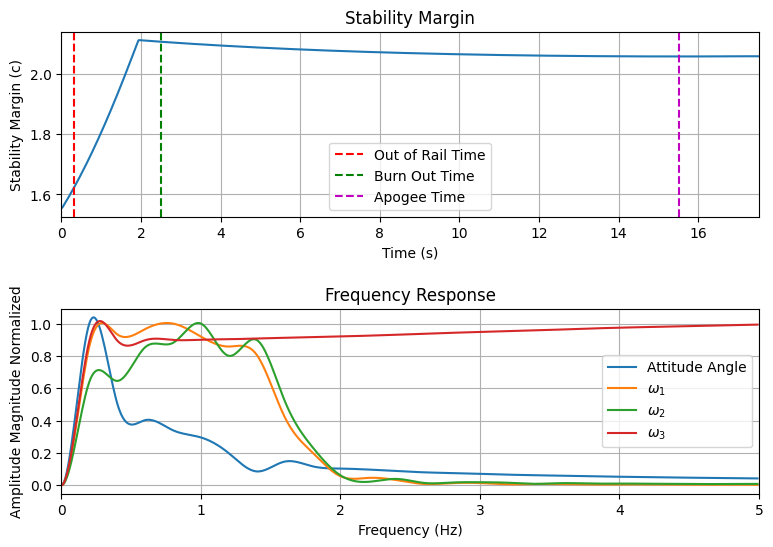



Rocket and Parachute Pressure Plots



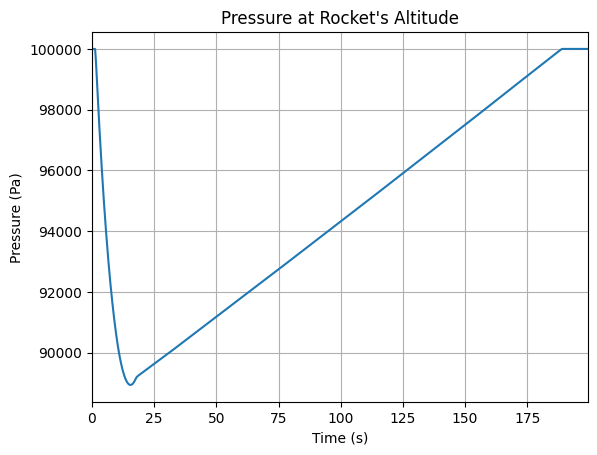


Parachute:  Main


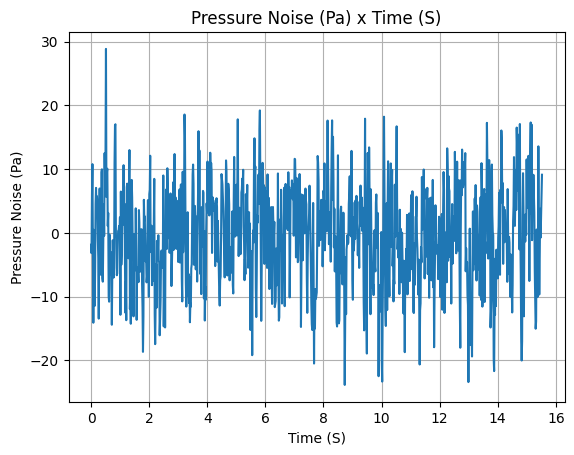

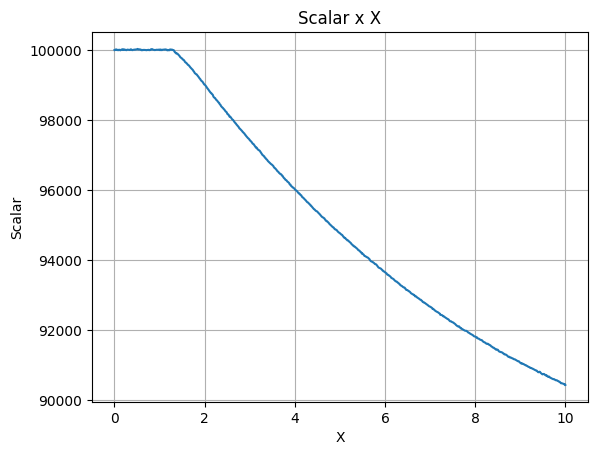

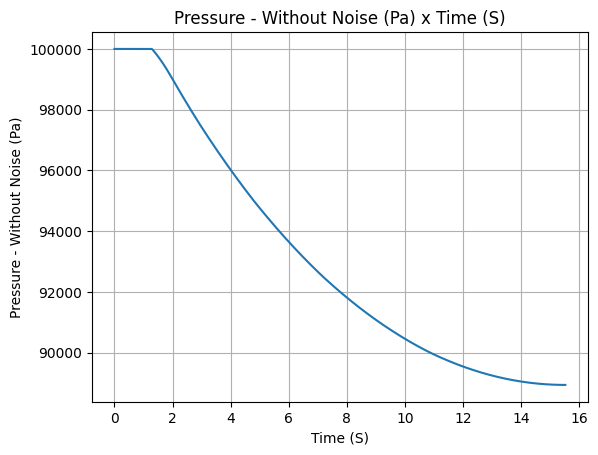

In [17]:
# Display all flight information
test_flight.all_info()

### Key Results Summary

**Expected Performance:**
- **Apogee:** ~1025 m AGL
- **Stability at Rail Exit:** ~1.95 calibers
- **Drift Distance:** ~343 m (typical wind conditions)

### Export Trajectory

Export flight path to KML format for visualization in Google Earth.

In [18]:
# Export trajectory to KML
test_flight.export_kml(
    file_name=str(OUTPUT_DIR / "trajectory.kml"),
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  ..\output\trajectory.kml  saved with success!


## Design Utilities

### Apogee vs. Mass Analysis

Understand how payload mass affects maximum altitude.

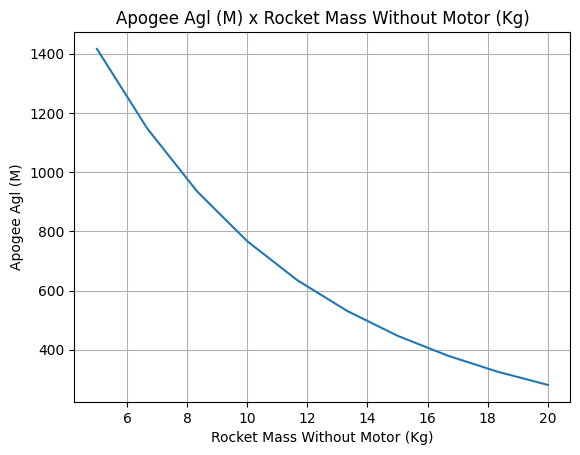

'Function from R1 to R1 : (Rocket Mass without motor (kg)) → (Apogee AGL (m))'

In [19]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(
    flight=test_flight,
    min_mass=5,
    max_mass=20,
    points=10,
    plot=True
)

### Rail Exit Velocity vs. Mass

Ensure adequate exit velocity for stable flight.

> **Rule of Thumb:** Rail exit velocity should be ≥4× wind speed.

In [ ]:
from rocketpy.utilities import liftoff_speed_by_mass

liftoff_speed_by_mass(
    flight=test_flight,
    min_mass=5,
    max_mass=20,
    points=10,
    plot=True
)

### Dynamic Stability Analysis

Analyze how static margin affects flight dynamics.

In [ ]:
from rocketpy import Function
import copy

# Create a copy for parametric study
PIONEER2 = copy.deepcopy(PIONEER)

# Custom environment with constant crosswind
custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

# Simulate different static margins
simulation_results = []

for factor in [-0.5, -0.2, 0.1, 0.4, 0.7]:
    # Modify fin position
    PIONEER2.aerodynamic_surfaces.pop(-1)
    fin_set = PIONEER2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=-1.04956 * factor,
    )
    
    print(f"Static Margin: {PIONEER2.static_margin(0):.3f} -> {PIONEER2.static_margin(PIONEER2.motor.burn_out_time):.3f} cal")
    
    flight = Flight(
        rocket=PIONEER2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=5,
        terminate_on_apogee=True,
        verbose=True,
    )
    
    simulation_results.append((
        flight.attitude_angle,
        f"{PIONEER2.static_margin(0):.2f} c | {PIONEER2.static_margin(flight.out_of_rail_time):.2f} c | {PIONEER2.static_margin(flight.t_final):.2f} c"
    ))

Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Time (s)",
    ylabel="Attitude Angle (deg)",
)

### Frequency Response Analysis

Analyze characteristic oscillation frequencies during powered flight.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Short simulation for frequency analysis
freq_flight = Flight(
    rocket=PIONEER,
    environment=env,
    rail_length=4,
    inclination=85,
    heading=0,
    max_time_step=0.01,
    max_time=5,
)

# Fourier analysis parameters
Fs = 100.0  # Sampling rate (Hz)
Ts = 1.0 / Fs
t = np.arange(1, 400, Ts)

# Extract attitude angle and remove DC component
y = freq_flight.attitude_angle(t) - np.mean(freq_flight.attitude_angle(t))
n = len(y)

# Compute FFT
frq = np.arange(n) / (n / Fs)
frq = frq[:n // 2]
Y = np.fft.fft(y) / n
Y = Y[:n // 2]

# Plot results
fig, ax = plt.subplots(2, 1, figsize=(10, 6))

ax[0].plot(t, y)
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Attitude Angle (deg)")
ax[0].set_xlim((0, 5))
ax[0].set_title("Time Domain")
ax[0].grid(True)

ax[1].plot(frq, np.abs(Y), 'r')
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|Y(f)|")
ax[1].set_xlim((0, 5))
ax[1].set_title("Frequency Spectrum")
ax[1].grid(True)

plt.tight_layout()
plt.show()